# Simple CTI Recommender
This notebook fetches recent CVEs from NVD and the CISA KEV catalog, applies a simple scoring heuristic (recency, CVSS, KEV membership), runs EDA, and emits recommendation outputs.
Sections: Imports/config, Caching, Fetchers, Scoring, EDA/Evaluation, Main driver.

## Imports and configuration
This cell contains the runtime configuration constants and library imports used across the notebook. Keep this cell at the top so the kernel has consistent globals (API URLs, cache dir).

In [1]:
# Refactored core (part 1/6): imports and config
import requests
import pandas as pd
from datetime import datetime, timezone
from dateutil.parser import parse as parse_date
from pathlib import Path
from IPython.display import display

# Config
NVD_API_URL = "https://services.nvd.nist.gov/rest/json/cves/2.0"
CISA_KEV_URL = "https://www.cisa.gov/sites/default/files/csv/known_exploited_vulnerabilities.csv"
CACHE_DIR = Path("data_cache")
CACHE_DIR.mkdir(parents=True, exist_ok=True)


In [2]:
# Ensure inline plotting when running interactively
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = (8, 4)
print('Inline plotting enabled')

Inline plotting enabled


In [3]:
# Load cached data, score, and display top results inline
from cti_recommender import get_nvd_cached, get_kev_cached, build_simple_score
# Load cached NVD and KEV (uses data_cache/*.pkl.gz)
nvd = get_nvd_cached(days_back=30, ttl_hours=6.0)
kev = get_kev_cached(ttl_days=1)
# Merge to add kev_flag
kev_small = kev[["cve_id"]].dropna().drop_duplicates().copy()
kev_small['kev_flag'] = 1
merged = pd.merge(nvd, kev_small, on="cve_id", how="left")
merged['kev_flag'] = merged['kev_flag'].fillna(0).astype(int)
# Score
scored = build_simple_score(merged)
scored_sorted = scored.sort_values(by='final_score', ascending=False)
from IPython.display import display
display(scored_sorted.head(20))

# Save outputs for programmatic runs (also shows inline plots below)
outputs_dir = Path('outputs')
outputs_dir.mkdir(parents=True, exist_ok=True)
try:
    scored_sorted.to_csv(outputs_dir / 'top_scored.csv', index=False)
    scored_sorted.head(20).to_csv(outputs_dir / 'top20.csv', index=False)
    merged.to_csv(outputs_dir / 'merged.csv.gz', index=False, compression='gzip')
except Exception:
    pass


INFO:cti_recommender:Loading NVD from cache: data_cache/nvd_30d.pkl.gz


INFO:cti_recommender:Loading KEV from cache: data_cache/kev_catalog.pkl.gz


,cve_id,published,description,cvss,kev_flag,recency_score,cvss_norm,final_score
284,CVE-2025-61932,2025-10-20T08:15:33.303,Lanscope Endpoint Manager (On-Premises) (Clien...,9.8,1,0.856,0.98,0.9384
1859,CVE-2025-12516,2025-10-30T16:15:35.110,Lack of Graceful Error Handling - HTTP 5xx Err...,9.8,0,0.917,0.98,0.5628
1968,CVE-2024-13994,2025-10-30T22:15:44.767,Nagios XI versions prior to 2024R1.1.2 contain...,9.8,0,0.917,0.98,0.5628
1858,CVE-2025-12515,2025-10-30T16:15:34.960,Systemic Internal Server Errors - HTTP 500 Res...,9.8,0,0.917,0.98,0.5628
1970,CVE-2024-13996,2025-10-30T22:15:45.043,Nagios XI versions prior to 2024R1.1.3 did not...,9.8,0,0.917,0.98,0.5628
1992,CVE-2025-34277,2025-10-30T22:15:48.227,Nagios Log Server versions prior to 2024R1.3.1...,9.8,0,0.917,0.98,0.5628
1991,CVE-2025-34274,2025-10-30T22:15:48.090,Nagios Log Server versions prior to 2024R2.0.3...,9.8,0,0.917,0.98,0.5628
1971,CVE-2024-13999,2025-10-30T22:15:45.180,"Nagios XI versions prior to 2024R1.1.3, under ...",9.8,0,0.917,0.98,0.5628
1975,CVE-2024-14003,2025-10-30T22:15:45.737,Nagios XI versions prior to 2024R1.2 are vulne...,9.8,0,0.917,0.98,0.5628
1988,CVE-2025-34271,2025-10-30T22:15:47.673,Nagios Log Server versions prior to 2024R2.0.2...,9.8,0,0.917,0.98,0.5628


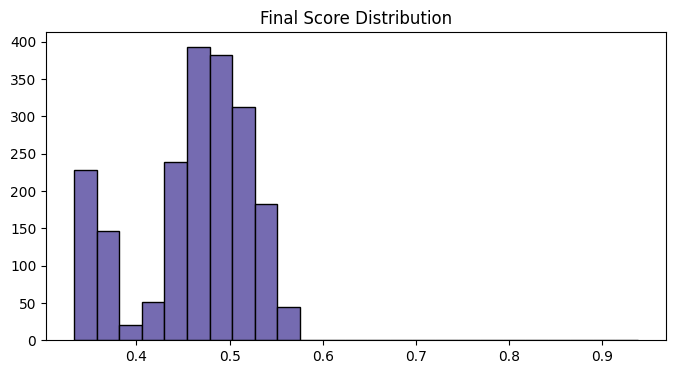

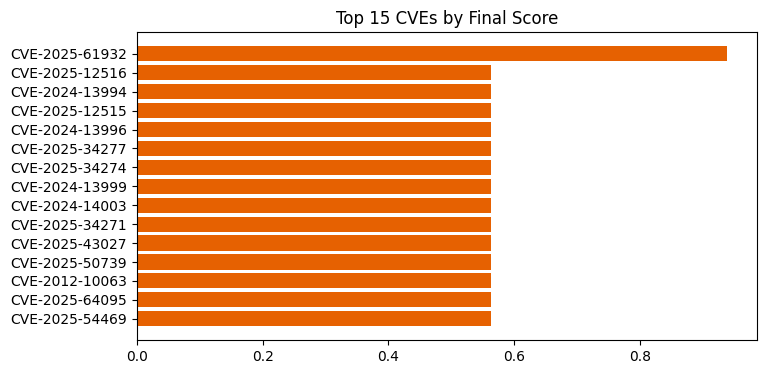

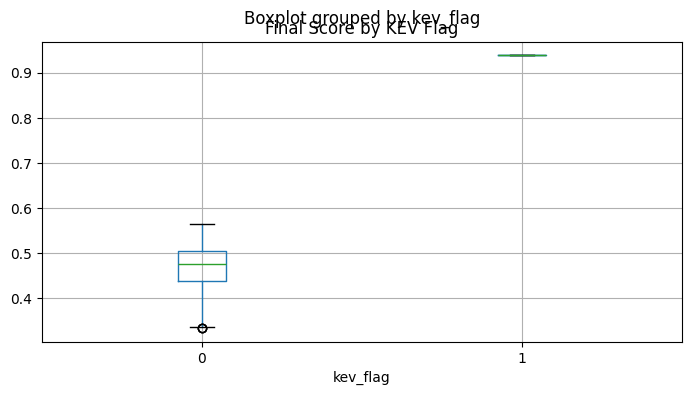

In [4]:
# EDA plots inline (and save) 
import matplotlib.pyplot as plt
# Histogram of final_score
vals = scored_sorted['final_score'].dropna()
fig, ax = plt.subplots()
ax.hist(vals, bins=25, color='#756bb1', edgecolor='black')
ax.set_title('Final Score Distribution')
display(fig)
fig.savefig(outputs_dir / 'final_score_hist.png')
plt.close(fig)

# Top 15 bar
topn = scored_sorted.head(15)
fig2, ax2 = plt.subplots(figsize=(8,4))
ax2.barh(topn['cve_id'].astype(str), topn['final_score'], color='#e66101')
ax2.invert_yaxis()
ax2.set_title('Top 15 CVEs by Final Score')
display(fig2)
fig2.savefig(outputs_dir / 'top15_bar.png')
plt.close(fig2)

# Boxplot by kev_flag
if 'kev_flag' in scored_sorted.columns:
    fig3, ax3 = plt.subplots()
    scored_sorted.boxplot(column='final_score', by='kev_flag', ax=ax3)
    ax3.set_title('Final Score by KEV Flag')
    display(fig3)
    fig3.savefig(outputs_dir / 'score_by_kev.png')
    plt.close(fig3)


## Notes on outputs
- Inline plots appear when you run the notebook cells in a live kernel (Kernel → Restart & Run All).
- The notebook also saves PNGs and CSVs into `outputs/` for programmatic runs.
- If you want numeric evaluation metrics (precision@K etc.) I can add a cell to compute and save them.